## Análise do Comitê Agregado

Nesse notebook vamos fazer a análise do comitê para avaliar a qualidade do modelos (Multimodais & Baseline + Multimodais).

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score

from evaluations.metrics import plot_roc_curves, tar_at_far
from dataset.pairs.bin_reader import FacePairBinReader
from dataset.pairs.bin_visualizer import FacePairVisualizer
from utils.config_loader import Config
from utils.paths import ProjectPathResolver
from utils import analytics_tools as at

In [2]:
sns.set_theme(style="whitegrid")

config_fpe = Config(path="config.fc_pair_eval.yaml")
path_resolver_fpe = ProjectPathResolver(config_fpe)

output_dir = path_resolver_fpe["paths.results_dir"]
os.makedirs(output_dir, exist_ok=True)
AGG_PLOTS_DIR = path_resolver_fpe["paths.all_aggregations_plot_dir"]
AGGREGATION_DIR = path_resolver_fpe["paths.all_aggregations_dir"]
PAIR_IMAGES_DIR = path_resolver_fpe["paths.pair_images_dir"]

In [3]:
reader = FacePairBinReader(path_resolver_fpe['paths.bin_subset'].path)
pairs = reader.load_pil_pairs()

In [4]:
df_committee_fcw112 = pd.read_csv(output_dir / "pair-gt_labat-cropped_image-warpe-112x112-len1180" / "committee_full_analysis.csv")
df_committee_ffidr = pd.read_csv(output_dir / "pair-gt_labat-full_image-default_480x640-len1180" / "committee_full_analysis.csv")

fv_output_dir = Path("/path/to/your/consolidated/output/directory/face_verification")
df_baseline_all_models_fcw112 = pd.read_csv(fv_output_dir / "pair-gt_labat-cropped_image-warpe-112x112-len1180" / "pairs_predictions_all_models.csv")
df_baseline_all_models_ffidr = pd.read_csv(fv_output_dir / "pair-gt_labat-full_image-default_480x640-len1180" / "pairs_predictions_all_models.csv")

In [5]:
position = df_committee_fcw112.columns.get_loc('pair_id') + 1
df_committee_fcw112.insert(loc=position, column='pair_set', value="FCW112")
df_committee_ffidr.insert(loc=position, column='pair_set', value="FFIDR")
df_baseline_all_models_fcw112.insert(loc=position, column='pair_set', value="FCW112")
df_baseline_all_models_ffidr.insert(loc=position, column='pair_set', value="FFIDR")

print(f"Length of FCW112 Full Committee {len(df_committee_fcw112)}")
print(f"Length of FFIDR Full Committee {len(df_committee_ffidr)}")
print(f"Length of FCW112 Full Baseline {len(df_baseline_all_models_fcw112)}")
print(f"Length of FFIDR Full Baseline {len(df_baseline_all_models_ffidr)}")

Length of FCW112 Full Committee 1180
Length of FFIDR Full Committee 1180
Length of FCW112 Full Baseline 1180
Length of FFIDR Full Baseline 1180


In [6]:
df_all_committee = pd.concat([df_committee_fcw112, df_committee_ffidr], ignore_index=True)
print(f"Length of All Full Committee Aggregation {len(df_all_committee)}")

df_all_baseline = pd.concat([df_baseline_all_models_fcw112, df_baseline_all_models_ffidr], ignore_index=True)
print(f"Length of All Full Baseline Aggregation {len(df_all_baseline)}")

Length of All Full Committee Aggregation 2360
Length of All Full Baseline Aggregation 2360


In [7]:
df_all = pd.merge(
    df_all_committee,
    df_all_baseline,
    on=["pair_id", "pair_set"],   # chaves de junção
    how="inner",                  # ou "left", dependendo do que você quer
    suffixes=("_committee", "_baseline"),
)
print(len(df_all))
df_all

2360


,pair_id,pair_set,ground_truth_fraude,pred_gemini,pred_chatgpt,pred_claude,justificativa_gemini,justificativa_chatgpt,justificativa_claude,similaridade_gemini,...,claude_input_tokens,claude_output_tokens,claude_total_tokens,ground_truth_is_same,score_similaridade_ViT-face,pred_fraude_ViT-face,score_similaridade_arcface-buffalo_l,pred_fraude_arcface-buffalo_l,score_similaridade_adaface,pred_fraude_adaface
0,0,FCW112,False,False,False,False,"Os traços faciais, incluindo formato do nariz,...",Traços faciais e características semelhantes.,Traços faciais correspondentes: formato do ros...,0.92,...,360.0,62.0,422.0,True,0.539921,True,0.422707,False,0.486679,False
1,1,FCW112,False,False,False,False,"Traços faciais como formato do nariz, olhos, b...",Traços faciais e estrutura semelhantes.,Traços faciais correspondentes: formato do ros...,0.92,...,360.0,63.0,423.0,True,0.663795,False,0.656062,False,0.724300,False
2,2,FCW112,False,False,True,True,"Traços faciais como barba, bigode, formato do ...",Diferenças na iluminação e ângulo afetam a com...,Características faciais distintas. Formato do ...,0.92,...,360.0,65.0,425.0,True,0.625526,False,0.102958,True,0.372621,False
3,3,FCW112,False,False,False,False,"Traços faciais como formato do rosto, nariz, b...",Traços faciais e estrutura do rosto são muito ...,Traços faciais correspondentes: formato do ros...,0.92,...,360.0,59.0,419.0,True,0.665465,False,0.613319,False,0.723384,False
4,4,FCW112,False,False,True,False,"Traços faciais, formato do nariz, barba e bigo...",Diferenças notáveis na estrutura facial e no f...,Traços faciais correspondentes: formato do ros...,0.91,...,360.0,61.0,421.0,True,0.389802,True,0.015641,True,0.142696,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2355,1175,FFIDR,True,True,True,True,As imagens mostram pessoas de gêneros e caract...,Características faciais e gênero não correspondem,"Estrutura facial, formato do nariz e caracterí...",0.00,...,1156.0,57.0,1213.0,False,0.458036,True,0.114065,True,0.069297,True
2356,1176,FFIDR,True,True,True,False,As imagens mostram indivíduos de sexos e carac...,Imagens mostram pessoas diferentes em caracter...,"Traços faciais correspondentes: formato nariz,...",0.05,...,1156.0,82.0,1238.0,False,0.470497,True,0.010559,True,-0.040406,True
2357,1177,FFIDR,True,True,True,True,As imagens mostram pessoas de gêneros e caract...,Características faciais e estrutura do rosto s...,"Sexo, estrutura facial e traços distintivos co...",0.00,...,1156.0,55.0,1211.0,False,0.517700,True,0.105901,True,0.083696,True
2358,1178,FFIDR,True,True,True,True,As imagens mostram pessoas de gêneros distinto...,Traços faciais e características físicas não c...,Qualidade insuficiente para análise biométrica...,0.00,...,1156.0,81.0,1237.0,False,0.537010,True,-0.098524,True,-0.008152,True


In [8]:
y_fraud = (~df_all["ground_truth_is_same"]).astype(int).values

if "ground_truth_fraude" in df_all.columns:
    diff = (y_fraud != df_all["ground_truth_fraude"].astype(int).values).sum()
    print(f"Diferenças entre 'ground_truth_is_same' e 'ground_truth_fraude': {diff}")

roc_inputs: dict[str, tuple[np.ndarray, np.ndarray]] = {}

# ---------- Multimodais (LLMs) ----------
# score_fraude = 1 - similaridade_gemini (maior = mais provável ser fraude)
roc_inputs["Gemini 2.5 Flash"] = (
    1.0 - df_all["similaridade_gemini"].astype(float).values,
    y_fraud,
)
roc_inputs["ChatGPT-4o Mini"] = (
    1.0 - df_all["similaridade_chatgpt"].astype(float).values,
    y_fraud,
)
roc_inputs["Claude 4.5 Haiku"] = (
    1.0 - df_all["similaridade_claude"].astype(float).values,
    y_fraud,
)

# ---------- Baselines de face verification ----------
roc_inputs["ViT-face"] = (
    1.0 - df_all["score_similaridade_ViT-face"].astype(float).values,
    y_fraud,
)
roc_inputs["ArcFace (buffalo_l)"] = (
    1.0 - df_all["score_similaridade_arcface-buffalo_l"].astype(float).values,
    y_fraud,
)
roc_inputs["AdaFace"] = (
    1.0 - df_all["score_similaridade_adaface"].astype(float).values,
    y_fraud,
)

len(roc_inputs)

Diferenças entre 'ground_truth_is_same' e 'ground_truth_fraude': 0


6

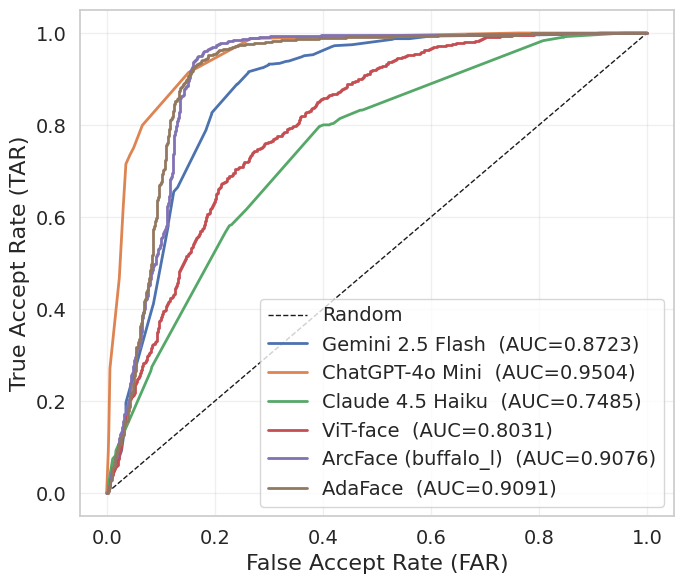

In [9]:
fig = plot_roc_curves(
    roc_inputs,
    title="ROC – Fraud Detection (TAR × FAR)\nAggregating FCW112 + FFIDR"
)
at.save_plot(fig, AGG_PLOTS_DIR, "roc_all_curves_aggregating_pairs.png")
plt.show()

In [10]:
rows = []
for model_name, (scores, labels) in roc_inputs.items():
    tar_dict = tar_at_far(scores, labels, far_targets=(0.001, 0.01, 0.1))
    row = {"model": model_name}
    row.update(tar_dict)
    rows.append(row)

df_tar = pd.DataFrame(rows)

# Ordena do melhor para o pior em FAR=1%
df_tar = df_tar.sort_values("TAR@FAR=1.0%", ascending=False)

df_tar

,model,TAR@FAR=0.1%,TAR@FAR=1.0%,TAR@FAR=10.0%
1,ChatGPT-4o Mini,0.000000,0.271408,0.799710
4,ArcFace (buffalo_l),0.000000,0.052975,0.541364
3,ViT-face,0.000000,0.038462,0.379536
5,AdaFace,0.001451,0.034107,0.673440
2,Claude 4.5 Haiku,0.000000,0.017417,0.274311
0,Gemini 2.5 Flash,0.000000,0.000000,0.411466


In [11]:
df_tar_fmt = df_tar.copy()
for col in df_tar.columns:
    if col.startswith("TAR@FAR="):
        df_tar_fmt[col] = (df_tar_fmt[col] * 100).map(lambda v: f"{v:.2f}%")
df_tar_fmt

,model,TAR@FAR=0.1%,TAR@FAR=1.0%,TAR@FAR=10.0%
1,ChatGPT-4o Mini,0.00%,27.14%,79.97%
4,ArcFace (buffalo_l),0.00%,5.30%,54.14%
3,ViT-face,0.00%,3.85%,37.95%
5,AdaFace,0.15%,3.41%,67.34%
2,Claude 4.5 Haiku,0.00%,1.74%,27.43%
0,Gemini 2.5 Flash,0.00%,0.00%,41.15%


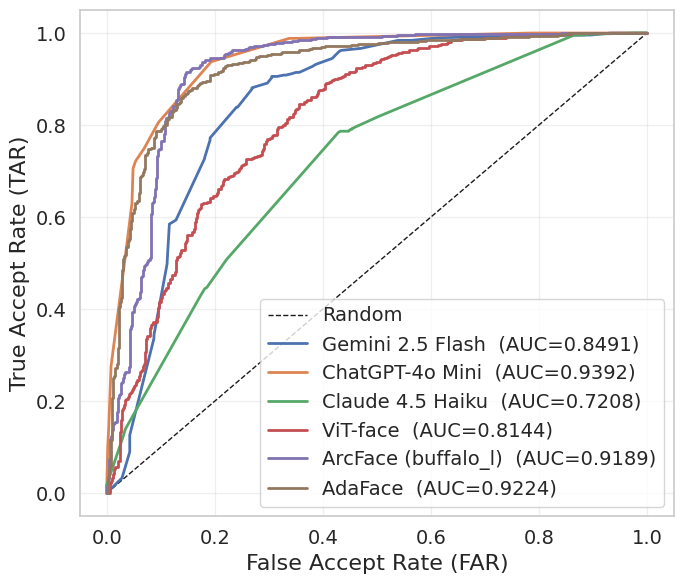

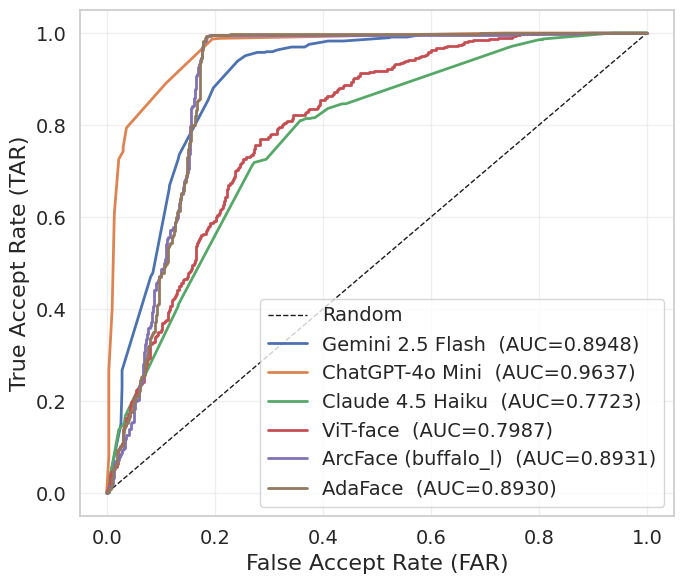

In [12]:
def build_roc_inputs_for_subset(df_subset: pd.DataFrame) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    y_fraud = (~df_subset["ground_truth_is_same"]).astype(int).values
    return {
        "Gemini 2.5 Flash": (1.0 - df_subset["similaridade_gemini"].astype(float).values, y_fraud),
        "ChatGPT-4o Mini": (1.0 - df_subset["similaridade_chatgpt"].astype(float).values, y_fraud),
        "Claude 4.5 Haiku": (1.0 - df_subset["similaridade_claude"].astype(float).values, y_fraud),
        "ViT-face": (1.0 - df_subset["score_similaridade_ViT-face"].astype(float).values, y_fraud),
        "ArcFace (buffalo_l)": (1.0 - df_subset["score_similaridade_arcface-buffalo_l"].astype(float).values, y_fraud),
        "AdaFace": (1.0 - df_subset["score_similaridade_adaface"].astype(float).values, y_fraud),
    }

for pairset in ["FCW112", "FFIDR"]:
    df_sub = df_all[df_all["pair_set"] == pairset]
    roc_inputs_sub = build_roc_inputs_for_subset(df_sub)
    fig = plot_roc_curves(
        roc_inputs_sub,
        title=f"ROC – Fraud Detection (TAR × FAR)\n{pairset}"
    )
    at.save_plot(fig, AGG_PLOTS_DIR, f"roc_curves_for_{pairset}.png")
    plt.show()